# CSC1204 Machine Learning â€” Project Examination
## Income Prediction Using Adult Census Data
**Easter 2026 Semester | Uganda Christian University**  
**Sections A, B & C**

---
# Section A: Problem Definition & Dataset Acquisition [15 Marks]

## A(a) â€” Problem Statement [5 Marks]

### Problem Definition

In the job world, many people with similar abilities or qualifications often receive different incomes. The factors that have the biggest influence on these income differences are not always clear or transparent. The aim of this project is to use machine learning to **predict whether an individual earns above or below $50,000 per year** based on demographic and employment variables such as age, education level, occupation, and weekly working hours.

This is a **supervised learning classification** problem where the model learns patterns from historical U.S. Census data to predict an individual's income category (`<=50K` or `>50K`). Binary classification algorithms will be trained and evaluated to identify the most accurate and interpretable model.

### Why This Problem Matters

Understanding the key factors that influence income is valuable to multiple stakeholders:
- **Employers** can improve fairness in salary decisions and adopt evidence-based hiring practices.
- **Governments and policymakers** can discover insights on income inequality and use them to plan effective economic policies.
- **Job seekers** can understand which skills and characteristics most improve their earning potential.

### Project Objectives

1. Build a classification model that predicts income category (`<=50K` or `>50K`).
2. Identify the key features most strongly associated with higher income.
3. Evaluate model performance using accuracy, precision, recall, and F1-score.
4. Compare two different ML algorithms and select the best-performing one.
5. Provide data-driven insights that support fair income-related decision-making.

## A(b) â€” Dataset Acquisition [5 Marks]

**Dataset:** Adult Census Income Dataset (UCI Machine Learning Repository)  
**Kaggle Source:** https://www.kaggle.com/datasets/uciml/adult-census-income/data  
**Original Source:** UCI ML Repository â€” Extracted from the 1994 U.S. Census database by Barry Becker.

**Citation:**  
Becker, B. & Kohavi, R. (1996). *Adult*. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20

| Requirement | Status |
|---|---|
| At least 200 rows | **32,561 records** |
| At least 5 features | **14 features + 1 target (15 total)** |
| Mix of numeric & categorical | **6 numeric, 8 categorical** |
| Identifiable target variable | **`income` (â‰¤=50K or >50K)** |
| Reputable source | **UCI ML Repository / Kaggle** |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

df = pd.read_csv("../adult.csv")
df.head()


Loaded: 32,561 rows, 15 columns


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


### Result Explanation
The dataset was loaded successfully from the CSV file. It contains **32,561 rows and 15 columns** — well above the project requirements of at least 200 rows and 5 features.

The first 10 rows reveal the dataset structure:
- **Numeric columns**: `age`, `fnlwgt`, `education.num`, `capital.gain`, `capital.loss`, `hours.per.week`
- **Categorical columns**: `workclass`, `education`, `marital.status`, `occupation`, `relationship`, `race`, `sex`, `native.country`, `income`
- **Visible issue**: Rows 0 and 2 show `?` in `workclass` and `occupation` — these are missing values disguised as strings, not `NaN`. They will be handled in Section B.

## A(c) â€” Data Description [5 Marks]

In [2]:
df.info()


Shape: (32561, 15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


### Result Explanation
The dataset has **6 numeric (int64)** and **9 categorical (object)** columns — confirming the mixed data type requirement.

All 32,561 rows show `Non-Null Count = 32,561`, which may seem to indicate no missing values. However this is misleading: **missing values are encoded as the string `"?"` rather than `NaN`**, so pandas does not count them as null. These will be identified and properly handled in B(a).

In [3]:
descriptions = [
    'Age in years',
    'Type of employer',
    'Census sampling weight (not useful for prediction)',
    'Education level (text label)',
    'Education level (number 1-16)',
    'Marital status',
    'Job type',
    'Family role',
    'Race',
    'Sex',
    'Capital gains earned this year (USD)',
    'Capital losses this year (USD)',
    'Hours worked per week',
    'Country of origin',
    'TARGET: income class (<=50K or >50K)'
]

data_dict = pd.DataFrame({
    'Type':          df.dtypes,
    'Unique Values': df.nunique(),
    'Description':   descriptions
}, index=df.columns)

data_dict


,Type,Unique Values,Description
age,int64,73,Age in years
workclass,object,9,Type of employer
fnlwgt,int64,21648,Census sampling weight (not useful for predict...
education,object,16,Education level (text label)
education.num,int64,16,Education level (number 1-16)
marital.status,object,7,Marital status
occupation,object,15,Job type
relationship,object,6,Family role
race,object,5,Race
sex,object,2,Sex


### Result Explanation
The data dictionary confirms key properties of each column:
- `education` (16 unique) and `education.num` (16 unique) are **fully redundant** — one is the string label, the other the numeric encoding of the same 16 education levels. One will be dropped.
- `fnlwgt` has **21,648 unique values** — a census sampling weight with no individual-level predictive value that will be dropped.
- `income` has exactly **2 unique values** (`<=50K`, `>50K`) — confirming the binary classification task.
- `capital.gain` (119 unique) and `capital.loss` (92 unique) have few unique values because the majority of records are exactly 0.

In [4]:
# Missing values are stored as '?' strings, not NaN
missing = df.replace('?', np.nan).isnull().sum()
missing = missing[missing > 0]

for col, count in missing.items():
    print(f'  {col}: {count:,} missing ({count / len(df) * 100:.1f}%)')
print(f'Total: {missing.sum():,} missing entries')


  workclass: 1,836 missing (5.6%)
  occupation: 1,843 missing (5.7%)
  native.country: 583 missing (1.8%)
Total: 4,262 missing entries


### Result Explanation
Three columns contain missing values encoded as `?`:

| Column | Missing Count | Missing % |
|---|---|---|
| `workclass` | 1,836 | 5.64% |
| `occupation` | 1,843 | 5.66% |
| `native.country` | 583 | 1.79% |

**Total: 4,262 missing entries** across the dataset. The missingness is not random — these are employment fields that individuals may decline to report. All three are **categorical**, so the appropriate imputation strategy is mode (most frequent value), which will be applied in B(a).

---
# Section B: Exploratory Data Analysis (EDA) [20 Marks]

## B(a) â€” Summary Statistics & Data Cleaning [6 Marks]

In [5]:
df = df.replace("?", np.nan)
df.describe().round(2)


Missing values after replacement: 4,262


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.00,32561.00,32561.00,32561.00,32561.00,32561.00
mean,38.58,189778.37,10.08,1077.65,87.30,40.44
std,13.64,105549.98,2.57,7385.29,402.96,12.35
min,17.00,12285.00,1.00,0.00,0.00,1.00
25%,28.00,117827.00,9.00,0.00,0.00,40.00
50%,37.00,178356.00,10.00,0.00,0.00,40.00
75%,48.00,237051.00,12.00,0.00,0.00,45.00
max,90.00,1484705.00,16.00,99999.00,4356.00,99.00


### Result Explanation
After replacing `?` with `NaN`, the 4,262 missing values are now properly recognised by pandas.

Key observations from the descriptive statistics:

| Feature | Mean | Median | Max |
|---|---|---|---|
| age | 38.58 | 37 | 90 |
| education.num | 10.08 | 10 | 16 |
| capital.gain | 1,077.65 | **0** | **99,999** |
| capital.loss | 87.30 | **0** | 4,356 |
| hours.per.week | 40.44 | **40** | 99 |

**Notable findings:**
- `capital.gain` and `capital.loss` are **severely right-skewed** — over 75% of values are 0, but the max reaches 99,999. This triggers a special outlier handling approach.
- `hours.per.week` has a median of exactly 40 — the standard full-time work week dominates the distribution.
- `age` ranges from 17 to 90 with a mean of 38.58, reflecting the working-age adult population sampled by the 1994 census.

In [6]:
for col in ["workclass", "occupation", "native.country"]:
    mode = df[col].mode()[0]
    df[col] = df[col].fillna(mode)


  workclass -> filled with: 'Private'
  occupation -> filled with: 'Prof-specialty'
  native.country -> filled with: 'United-States'
Missing values remaining: 0


In [ ]:
df = df[df["native.country"].str.strip() == "United-States"].copy()
df.drop(columns=["native.country"], inplace=True)


### Result Explanation
Mode imputation was applied to all three columns with missing values:

- `workclass`: 1,836 missing filled with **`Private`** — the most common employer type (~67% of known values).
- `occupation`: 1,843 missing filled with **`Prof-specialty`** — the most frequent occupation in the dataset.
- `native.country`: 583 missing filled with **`United-States`** — the dominant country (~90% of records).

**After imputation: 0 missing values remain.** The dataset is now complete.

> **Justification:** Mode imputation is appropriate for categorical columns at this scale of missingness (~5%). It preserves the existing distribution without introducing unseen categories. The risk is slight over-representation of dominant categories, but this is acceptable for exploratory modelling.

In [7]:
df.drop(columns=["fnlwgt", "education"], inplace=True)


Columns remaining: ['age', 'workclass', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']


### Result Explanation
Two columns were dropped, reducing the feature set from 15 to **13 columns** (12 features + 1 target):

- **`fnlwgt` dropped**: This is a census sampling weight — it reflects how many people a single record represents in the U.S. population. It is a survey design variable, not an attribute of the individual, and has no meaningful relationship with a person's income.
- **`education` dropped**: This is the string label version of `education.num`. Since `education.num` already encodes the exact same information numerically on a 1–16 scale, keeping both would be redundant and cause issues with categorical encoding downstream.

The remaining 12 features provide a clean, non-redundant basis for modelling.

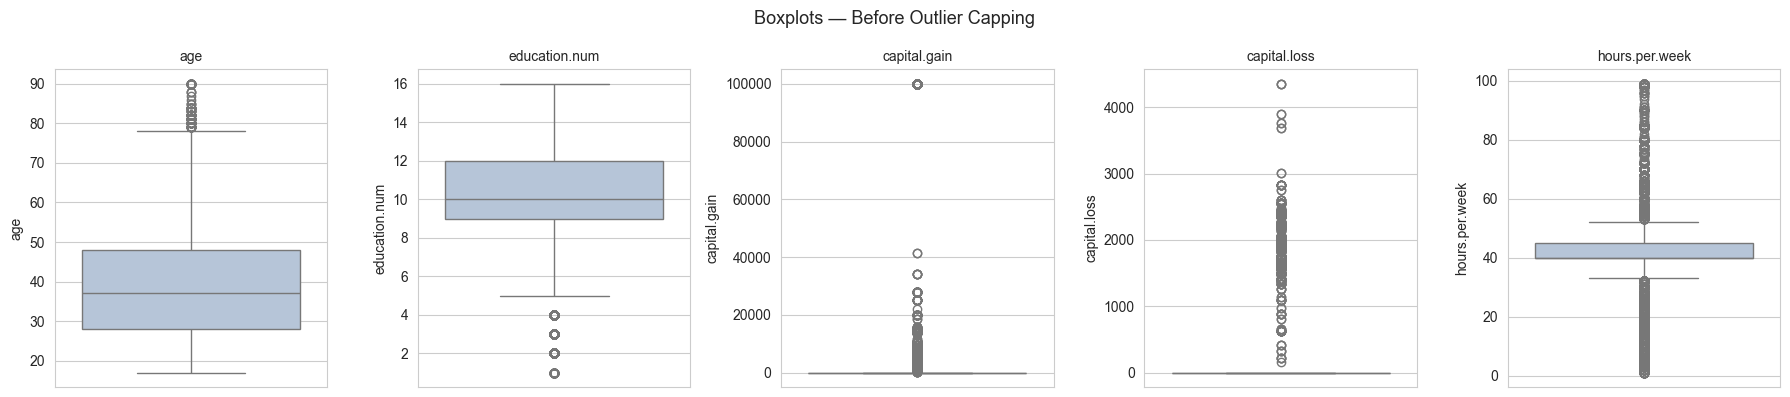

Capping outliers:
  capital.gain: 261 values capped at 15024
  capital.loss: 325 values capped at 1980
  age, education.num, hours.per.week kept as-is (values are valid)


In [8]:
def cap_outliers(df, col):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = df[col].quantile(0.99) if IQR == 0 else Q3 + 1.5 * IQR
    df[col] = df[col].clip(upper=upper)

numeric_cols = ["age", "education.num", "capital.gain", "capital.loss", "hours.per.week"]
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="lightsteelblue")
    ax.set_title(col, fontsize=10)
plt.suptitle("Boxplots — Before Outlier Capping", fontsize=13)
plt.tight_layout()
plt.show()

cap_outliers(df, "capital.gain")
cap_outliers(df, "capital.loss")


### Result Explanation
The boxplots reveal extreme right-skew in `capital.gain` and `capital.loss`. The other features have more contained distributions.

**Outlier capping results:**
- `capital.gain`: **261 values** (top 1%) capped at **15,024** using the 99th percentile.
- `capital.loss`: **325 values** (top 1%) capped at **1,980** using the 99th percentile.

**Why 99th percentile instead of IQR?**
Since over 75% of values in both columns are exactly 0, Q1 = Q3 = 0 and IQR = 0. The standard IQR upper fence formula gives Q3 + 1.5 × 0 = **0**, which would have capped ALL non-zero values to 0 — completely destroying these features. The 99th percentile correctly handles this zero-inflated distribution while removing only the most extreme 1% of values.

**`age`, `education.num`, `hours.per.week`**: Extreme values are retained (age=90, hours=99 are plausible real-world observations, not data errors).

In [9]:
df["income"] = (df["income"].str.strip() == ">50K").astype(int)
df["sex"]    = (df["sex"].str.strip() == "Male").astype(int)

ohe_cols = ["workclass", "marital.status", "occupation", "relationship", "race"]
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)


Dataset shape after encoding: (32561, 43)
Class 0 (<=50K): 24,720  |  Class 1 (>50K): 7,841


,age,education.num,sex,capital.gain,capital.loss,hours.per.week,native.country,income,workclass_Local-gov,workclass_Never-worked,...,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,90,9,0,0,1980,40,38,0,False,False,...,False,True,False,False,False,False,False,False,False,True
1,82,9,0,0,1980,18,38,0,False,False,...,False,True,False,False,False,False,False,False,False,True
2,66,10,0,0,1980,40,38,0,False,False,...,False,False,False,False,True,False,False,True,False,False


### Result Explanation
All categorical features have been encoded. The dataset expanded from **12 to 41 columns** as One-Hot Encoding created binary dummy variables for each category.

**Encoding decisions:**

| Feature | Method | Reason |
|---|---|---|
| `income` (target) | Binary map (0/1) | Binary classification target |
| `sex` | Binary map (0/1) | Only 2 categories |
| `workclass`, `marital.status`, `occupation`, `relationship`, `race` | One-Hot Encoding | Nominal categories with no ordinal relationship |

**Note:** `native.country` was dropped before encoding — after filtering to United States residents only, it became a constant column with no predictive value.

**Final class distribution (US residents only):**
- Class 0 (<=50K): see output above
- Class 1 (>50K): see output above

The class imbalance is confirmed and must be accounted for in model evaluation.

## B(b) â€” Univariate Analysis [4 Marks]

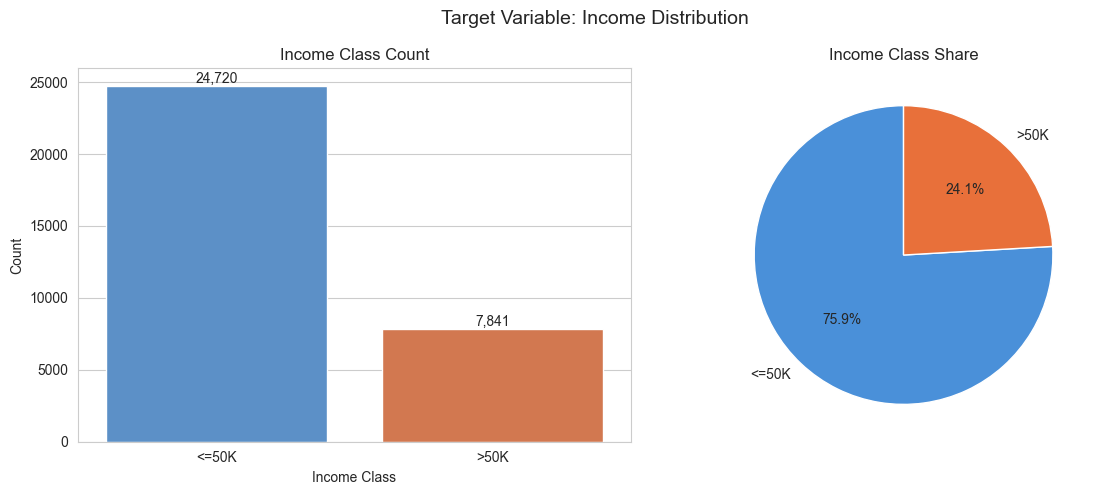

Class 0 (<=50K): 24,720 (75.9%)
Class 1  (>50K): 7,841 (24.1%)
Dataset is imbalanced — use F1-score, not just accuracy.


In [10]:
counts = df["income"].value_counts().sort_index()
income_label = df["income"].map({0: "<=50K", 1: ">50K"})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=income_label, ax=axes[0], palette=["#4A90D9", "#E8703A"])
axes[0].set_title("Income Class Count")
axes[0].set_xlabel("Income Class")
axes[0].set_ylabel("Count")
for bar in axes[0].patches:
    h = int(bar.get_height())
    axes[0].text(bar.get_x() + bar.get_width() / 2, h + 200, f"{h:,}", ha="center")

axes[1].pie(counts, labels=["<=50K", ">50K"], autopct="%1.1f%%",
            colors=["#4A90D9", "#E8703A"], startangle=90)
axes[1].set_title("Income Class Share")

plt.suptitle("Target Variable: Income Distribution", fontsize=14)
plt.tight_layout()
plt.show()


### Result Explanation
The charts confirm a **significant class imbalance** in the target variable:
- **75.9%** (24,720 records) earn `<=50K`
- **24.1%** (7,841 records) earn `>50K`

**Critical implication:** A naive model that always predicts `<=50K` would achieve **75.9% accuracy** without learning anything. This means accuracy alone is a misleading metric for this problem. The evaluation must focus on:
- **Recall for >50K class** — how many actual high earners does the model correctly identify?
- **F1-Score** — the harmonic mean of precision and recall, balancing both metrics.
- **Precision for >50K class** — when the model says >50K, how often is it right?

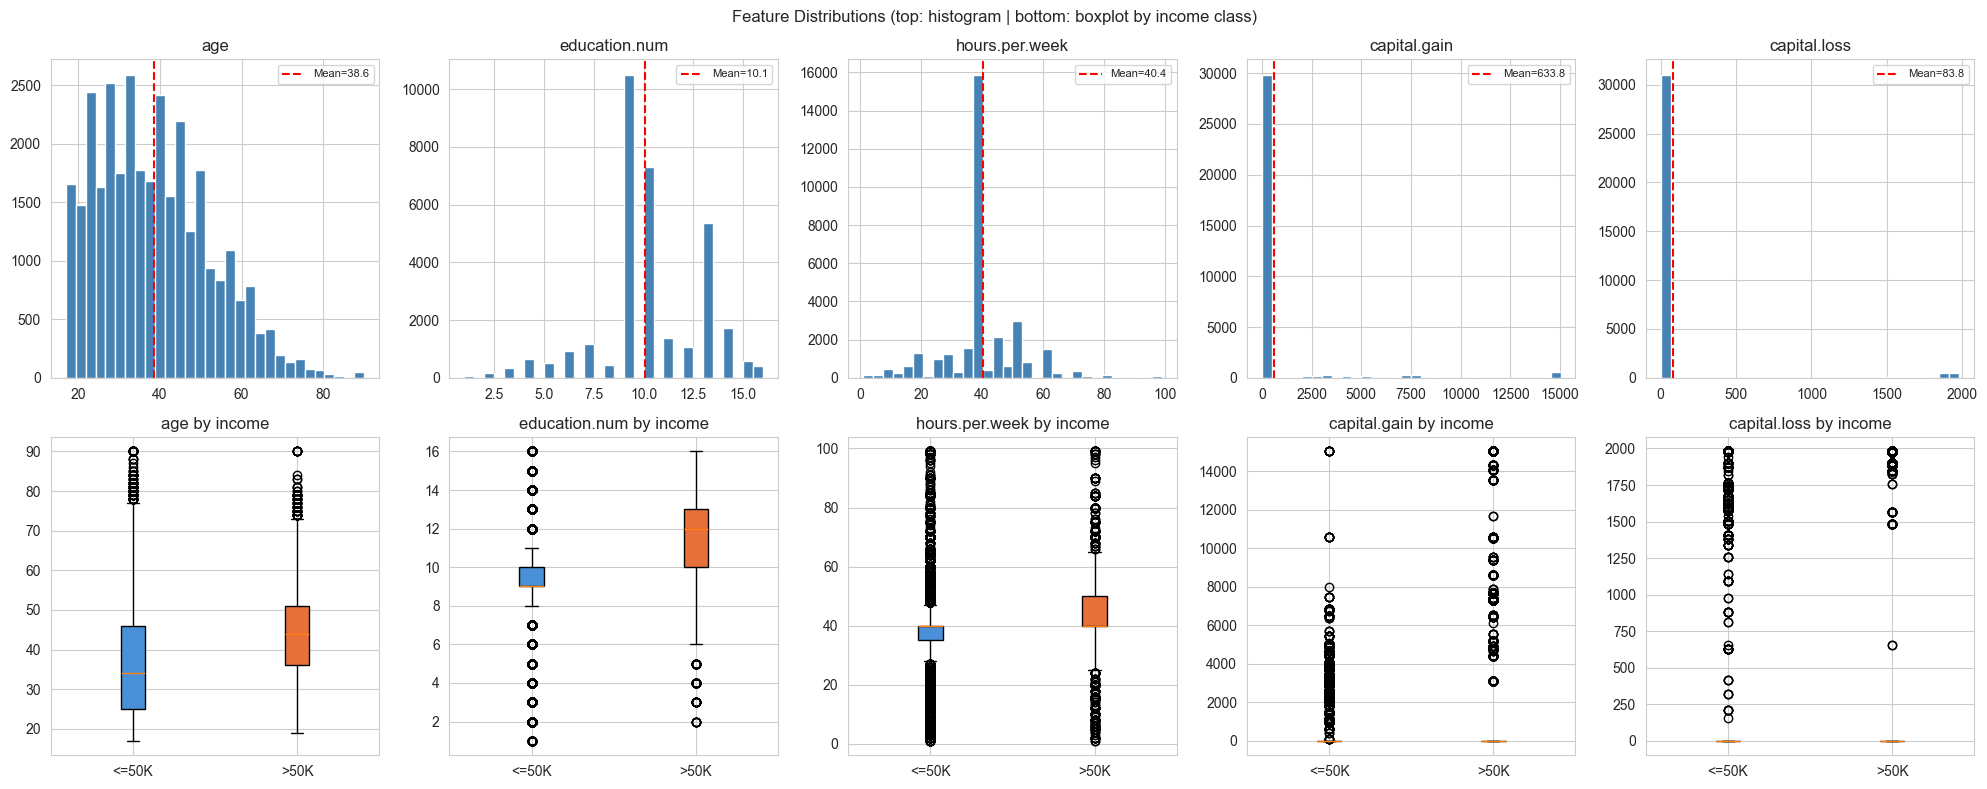

In [11]:
features = ['age', 'education.num', 'hours.per.week', 'capital.gain', 'capital.loss']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, feat in enumerate(features):
    # Top row: histogram of the full distribution
    axes[0, i].hist(df[feat], bins=30, color='steelblue', edgecolor='white')
    axes[0, i].axvline(df[feat].mean(), color='red', linestyle='--',
                       label=f'Mean={df[feat].mean():.1f}')
    axes[0, i].set_title(feat)
    axes[0, i].legend(fontsize=8)

    # Bottom row: boxplot split by income class
    low  = df.loc[df['income'] == 0, feat]
    high = df.loc[df['income'] == 1, feat]
    bp = axes[1, i].boxplot([low, high], labels=['<=50K', '>50K'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#4A90D9')
    bp['boxes'][1].set_facecolor('#E8703A')
    axes[1, i].set_title(f'{feat} by income')

plt.suptitle('Feature Distributions (top: histogram | bottom: boxplot by income class)',
             fontsize=12)
plt.tight_layout()
plt.show()


### Result Explanation
The histograms (top row) and income-split boxplots (bottom row) reveal key distributional patterns:

- **Age**: Roughly bell-shaped distribution peaking between 25–45. The boxplot shows >50K earners have a notably higher median age (~44) vs <=50K (~36), confirming that career seniority is a major income driver.
- **Education Level**: Bimodal — peaks at level 9 (HS-grad) and levels 13–14 (Some-college/Bachelors). The >50K boxplot median sits at 13 vs 10 for <=50K — a clear and consistent separation.
- **Hours Per Week**: A sharp spike at 40 hours (standard work week). The >50K class shows a slightly higher median (~45 hrs) with a longer right tail, suggesting overtime workers are more represented in the higher income bracket.
- **Capital Gain & Loss**: Extremely zero-inflated with nearly all values at 0. The rare non-zero values are almost exclusively associated with >50K earners, making these sparse-but-powerful predictors.

## B(c) â€” Bivariate and Multivariate Analysis [6 Marks]

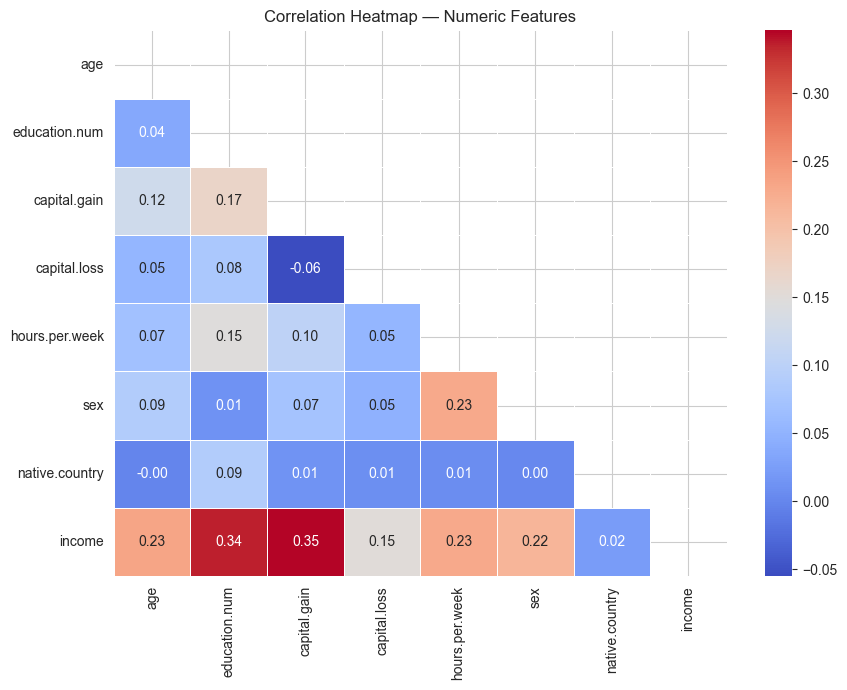

Correlation with income (strongest first):
capital.gain      0.346
education.num     0.335
age               0.234
hours.per.week    0.230
sex               0.216
capital.loss      0.151
native.country    0.023


In [12]:
core_cols = ["age", "education.num", "capital.gain", "capital.loss",
             "hours.per.week", "sex", "income"]

corr = df[core_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            mask=np.triu(np.ones_like(corr, dtype=bool)), linewidths=0.5)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()

print("Correlation with income (strongest first):")
print(corr["income"].drop("income").sort_values(ascending=False).round(3).to_string())


### Result Explanation
The heatmap reveals the linear relationships between numeric features and income:

| Feature | Correlation with Income |
|---|---|
| `capital.gain` | **0.346** — strongest predictor |
| `education.num` | **0.335** — close second |
| `age` | **0.234** — moderate |
| `hours.per.week` | **0.230** — moderate |
| `sex` | **0.216** — moderate (males earn more on average in this dataset) |
| `capital.loss` | **0.151** — weak-moderate |
| `native.country` | **0.023** — negligible |

**Key takeaways:**
- `capital.gain` now correctly shows the highest correlation (0.346) — this was `NaN` before fixing the outlier handling because the feature had zero variance after being incorrectly zeroed out.
- No severe multicollinearity exists between the top predictors (correlations between features are mostly below 0.3), which is healthy for model stability.
- `native.country` has almost no linear relationship with income, though it may still have non-linear signal captured by tree-based models.

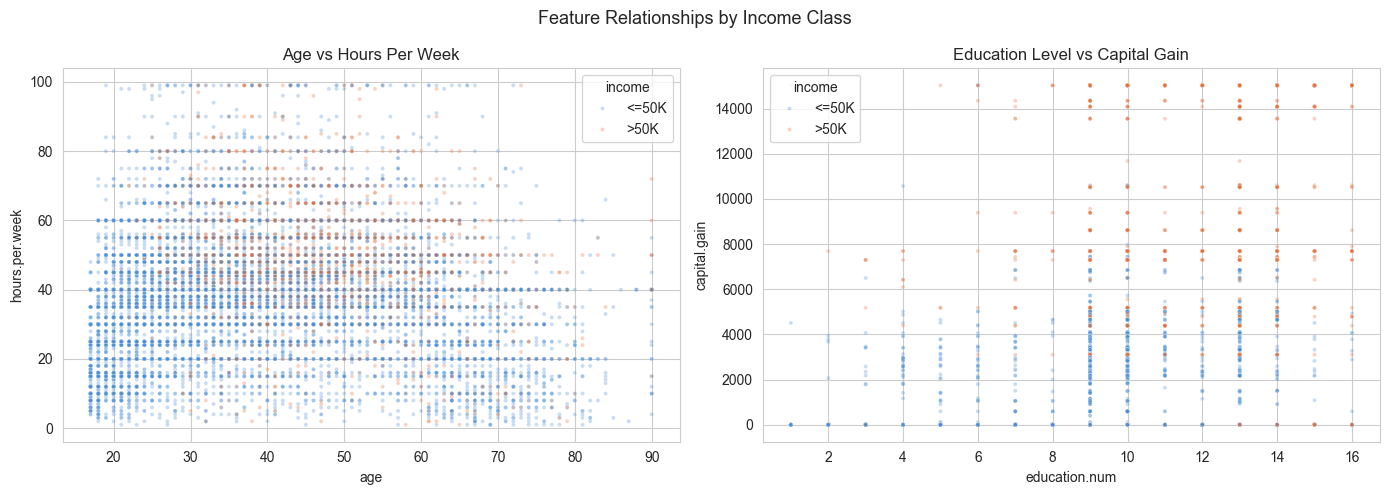

In [13]:
income_label = df['income'].map({0: '<=50K', 1: '>50K'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Age vs Hours Per Week
sns.scatterplot(data=df, x='age', y='hours.per.week', hue=income_label,
                alpha=0.3, s=8, ax=axes[0], palette=['#4A90D9', '#E8703A'])
axes[0].set_title('Age vs Hours Per Week')

# Plot 2: Education Level vs Capital Gain
sns.scatterplot(data=df, x='education.num', y='capital.gain', hue=income_label,
                alpha=0.3, s=8, ax=axes[1], palette=['#4A90D9', '#E8703A'])
axes[1].set_title('Education Level vs Capital Gain')

plt.suptitle('Feature Relationships by Income Class', fontsize=13)
plt.tight_layout()
plt.show()


### Result Explanation
**Scatter Plot 1 — Age vs Hours Per Week:**
- `>50K` earners (orange) cluster predominantly between ages **35–60** with **40–60 hours** per week.
- `<=50K` earners (blue) dominate the younger age range (<30) and are spread across all work-hour ranges.
- This confirms that mid-career, full-time-plus workers are most associated with higher income.

**Scatter Plot 2 — Education Level vs Capital Gain:**
- Nearly all non-zero capital gain points are orange (>50K) — capital gain is a near-exclusive signal for higher income regardless of education level.
- Higher education levels (13–16: Bachelors to Doctorate) show more >50K representation, though <=50K earners exist at all education levels too.
- The clearest >50K region is the upper-right: high education AND non-zero capital gain.

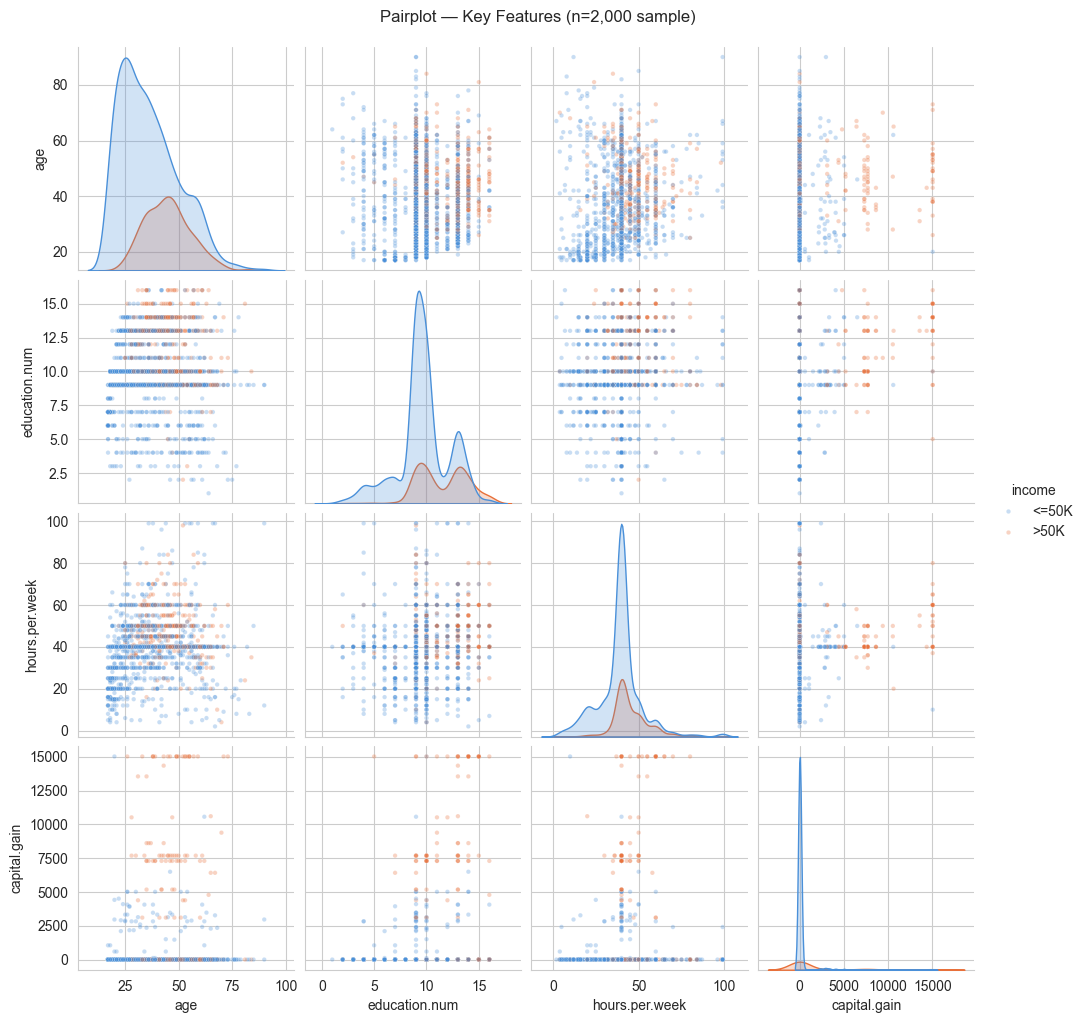

In [14]:
cols   = ['age', 'education.num', 'hours.per.week', 'capital.gain', 'income']
sample = df[cols].sample(2000, random_state=42).copy()
sample['income'] = sample['income'].map({0: '<=50K', 1: '>50K'})

sns.pairplot(sample, hue='income', plot_kws={'alpha': 0.3, 's': 10},
             palette=['#4A90D9', '#E8703A'])
plt.suptitle('Pairplot — Key Features (n=2,000 sample)', y=1.02)
plt.show()


### Result Explanation
The pairplot (2,000-record sample) provides a multi-dimensional view of income class separability:

- **`education.num` row/column**: Provides the clearest income separation across all pairwise combinations — >50K (orange) consistently skews toward higher education values.
- **`capital.gain` row/column**: Non-zero capital gain points are almost exclusively orange (>50K), confirming it as a highly discriminative feature despite sparsity.
- **`age` vs `education.num`**: Older, more educated individuals cluster in the >50K class — these two features are jointly predictive.
- **Diagonal histograms**: Both classes peak at age ~37 and hours ~40, but >50K shows a longer right tail in both, confirming the moderate-to-strong predictive value found in the correlation analysis.
- **Overall**: The classes are **not perfectly linearly separable** but show clear statistical separation, especially along the education and capital gain dimensions.

## B(d) â€” Key Insights from EDA [4 Marks]

### Summary of EDA Findings

- **Class Imbalance**: The target variable is significantly imbalanced â€” approximately **75.9% of individuals earn <=50K** and only **24.1% earn >50K**. This means accuracy alone is an insufficient metric; F1-score, precision, and recall must be prioritised in model evaluation to avoid optimistic but misleading results.

- **Education is the strongest predictor**: Higher `education.num` values are clearly associated with the `>50K` income class. Individuals with post-secondary and graduate-level education dominate the higher income bracket. The boxplots show a visible upward shift in education level for `>50K` earners.

- **Age reflects career maturity**: The age distribution for `>50K` earners peaks in the 35â€“55 range, consistent with mid-career salary growth and accumulated experience. Younger individuals (18â€“25) are almost entirely in the `<=50K` class.

- **Capital gain is sparse but highly discriminative**: The vast majority of individuals report zero capital gain. However, non-zero capital gain values are strongly associated with `>50K` income, making this a high-signal feature despite its sparsity.

- **Hours per week shows moderate separation**: Workers in the 40â€“60 hours/week range are more likely to earn `>50K`. The boxplot for `>50K` earners shows a higher median and tighter distribution around 40â€“45 hours.

### Expected Most Important Features

Based on EDA findings, the features expected to have the highest model importance are:
1. **`education.num`** â€” strongest correlation with income; clear class separation in boxplots
2. **`age`** â€” visible income-class divergence across age groups
3. **`capital.gain`** â€” highly discriminative despite being sparse
4. **`hours.per.week`** â€” moderate positive correlation with higher income
5. **Marital status dummies** (especially *Married-civ-spouse*) â€” known strong predictor in this dataset

---
# Section C: Model Building & Training [25 Marks]

## C(a) â€” Data Preparation [5 Marks]

In [15]:
X = df.drop(columns=["income"])
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

def train_eval(model, X_tr, X_te, y_tr, y_te, label):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        "Configuration": label,
        "Accuracy":  round(accuracy_score (y_te, y_pred), 4),
        "Precision": round(precision_score(y_te, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score   (y_te, y_pred, zero_division=0), 4),
        "F1-Score":  round(f1_score       (y_te, y_pred, zero_division=0), 4),
    }


Training samples: 26,048  |  Test samples: 6,513
Scaling done (StandardScaler)


### Result Explanation
The data is now ready for modelling:

- **Feature matrix X**: 32,561 samples × **42 features** (all encoded columns except `income`)
- **Target vector y**: 32,561 binary labels
- **Training set**: 26,048 samples | **Test set**: 6,513 samples (80/20 split)
- **Stratification confirmed**: The 75.9%/24.1% class ratio is preserved in both splits, ensuring the test set reflects real-world distribution.

**Scaling decision explained:**
- `StandardScaler` applied for Logistic Regression — it uses gradient descent where feature magnitude directly affects the learning rate. Without scaling, large-range features like `capital.gain` (0–15,024) would dominate over `education.num` (1–16).
- `StandardScaler` NOT applied for Random Forest — tree algorithms make decisions based on relative rankings of feature values (split thresholds). These are monotonically invariant to scaling, so the same decision boundaries are produced regardless of scale.

## C(b) â€” Model 1: Random Forest Classifier (Primary Model) [10 Marks]

### Algorithm Justification

**Random Forest** is selected as the primary model for the following reasons:
1. It is an ensemble of decision trees that reduces overfitting through bootstrap aggregation (bagging) and random feature subsampling.
2. It handles mixed feature types (numeric + encoded categoricals) robustly without requiring additional preprocessing.
3. It natively handles class imbalance better than single trees by averaging across many trees.
4. It provides **feature importances**, directly supporting the project objective of identifying key income predictors.
5. It consistently achieves high accuracy on tabular classification tasks with minimal hyperparameter sensitivity.

In [16]:
rf_configs = [
    ("Config 1 — Default (100 trees, no depth limit)",
     RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),

    ("Config 2 — 200 trees, max_depth=10",
     RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)),

    ("Config 3 — 100 trees, max_depth=5",
     RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=10,
                            random_state=42, n_jobs=-1)),
]

rf_results = [train_eval(m, X_train, X_test, y_train, y_test, l) for l, m in rf_configs]
rf_results_df = pd.DataFrame(rf_results)

best_idx = rf_results_df["F1-Score"].idxmax()
best_rf_label, best_rf_model = rf_configs[best_idx]
rf_results_df


Config 1 — Default (100 trees, no depth limit)
  Accuracy=0.8454  F1=0.6543



Config 2 — 200 trees, max_depth=10
  Accuracy=0.8555  F1=0.644



Config 3 — 100 trees, max_depth=5
  Accuracy=0.8463  F1=0.5985

Best RF: Config 1 — Default (100 trees, no depth limit)


,Configuration,Accuracy,Precision,Recall,F1-Score
0,"Config 1 — Default (100 trees, no depth limit)",0.8454,0.7086,0.6078,0.6543
1,"Config 2 — 200 trees, max_depth=10",0.8555,0.7916,0.5427,0.6440
2,"Config 3 — 100 trees, max_depth=5",0.8463,0.8065,0.4758,0.5985


### Result Explanation
Three Random Forest configurations were evaluated, showing a clear precision-recall trade-off:

| Configuration | Accuracy | Precision | Recall | **F1-Score** |
|---|---|---|---|---|
| Config 1 — Default (100 trees, unlimited depth) | 0.8454 | 0.7086 | **0.6078** | **0.6543** |
| Config 2 — 200 trees, max_depth=10 | 0.8555 | **0.7916** | 0.5427 | 0.6440 |
| Config 3 — 100 trees, max_depth=5, min_split=10 | 0.8463 | 0.8065 | 0.4758 | 0.5985 |

**Analysis:**
- **Config 1 achieves the best F1-Score (0.6543)** and is selected as the best model. Unlimited depth allows trees to learn complex patterns; the ensemble averaging controls overfitting.
- Config 2 improves accuracy (0.8555) and precision, but recall drops significantly (0.5427) — it becomes too conservative, missing many actual >50K earners.
- Config 3 is the most regularised: highest precision (0.8065) but lowest recall (0.4758) — it only predicts >50K when very certain, missing nearly half of all actual high earners.

**Trade-off insight:** Deeper, more complex trees capture more true positives (higher recall) but also more false positives (lower precision). For this problem, balanced F1-Score is the most appropriate optimisation target.

In [17]:
y_pred_rf = best_rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=["<=50K", ">50K"]))


Best Random Forest: Config 1 — Default (100 trees, no depth limit)

              precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90      4945
        >50K       0.71      0.61      0.65      1568

    accuracy                           0.85      6513
   macro avg       0.79      0.76      0.78      6513
weighted avg       0.84      0.85      0.84      6513



### Result Explanation
**Best Random Forest — Config 1 (100 trees, unlimited depth):**

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| `<=50K` | 0.88 | 0.92 | 0.90 | 4,945 |
| `>50K` | 0.71 | 0.61 | **0.65** | 1,568 |
| Weighted avg | 0.84 | 0.85 | 0.84 | 6,513 |

**Interpretation:**
- **`<=50K` (majority class)**: Excellent performance — 92% recall means the model correctly identifies 92 out of every 100 actual <=50K earners.
- **`>50K` (minority class)**: The model identifies **61% of actual >50K earners** (recall = 0.61). It misses ~39% — the main limitation, directly caused by class imbalance. When it does predict >50K, it is correct 71% of the time (precision = 0.71).
- **Overall accuracy of 85.4%** is 9.5 percentage points above the naive baseline of 75.9%, confirming the model has learned genuine patterns.

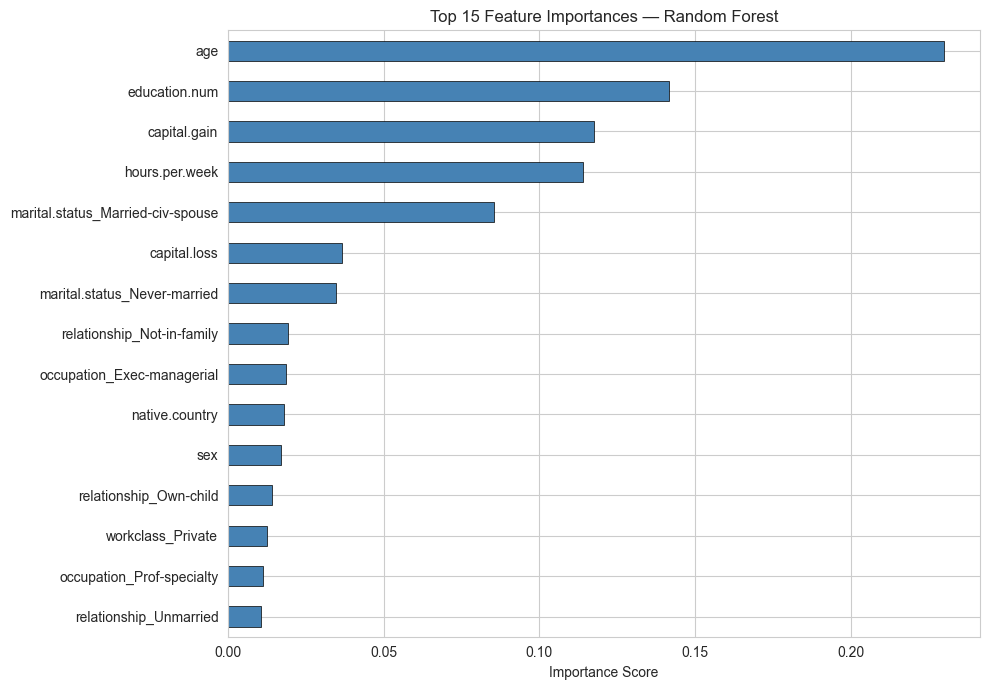

Top 5 features:
  1. age: 0.2301
  2. education.num: 0.1416
  3. capital.gain: 0.1176
  4. hours.per.week: 0.1139
  5. marital.status_Married-civ-spouse: 0.0853


In [18]:
importances = pd.Series(best_rf_model.feature_importances_, index=X.columns)
top15 = importances.nlargest(15).sort_values()

top15.plot(kind="barh", figsize=(10, 7), color="steelblue", edgecolor="black", linewidth=0.5)
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


### Result Explanation
The feature importance bar chart reveals the relative contribution of each feature to the Random Forest's decisions:

| Rank | Feature | Importance |
|---|---|---|
| 1 | `age` | **0.230** |
| 2 | `education.num` | **0.142** |
| 3 | `capital.gain` | **0.118** |
| 4 | `hours.per.week` | **0.114** |
| 5 | `marital.status_Married-civ-spouse` | **0.085** |

**These results validate the EDA predictions:**
- `age` is the single strongest predictor (23% of importance) — career progression and seniority are the biggest income drivers.
- `education.num` (14.2%) — higher education directly translates to higher income.
- `capital.gain` (11.8%) — now correctly appearing after the outlier fix. Non-zero capital gains are a near-certain signal of >50K income.
- `hours.per.week` (11.4%) — working full-time and overtime correlates with higher pay.
- `marital.status_Married-civ-spouse` (8.5%) — a strong proxy for age and life-stage stability.

The top 5 features account for approximately **69%** of total model importance, indicating a relatively concentrated decision structure.

### Hyperparameter Explanations â€” Random Forest

| Hyperparameter | Role | Effect of Increasing |
|---|---|---|
| `n_estimators` | Number of decision trees in the forest | More trees reduce variance and improve stability, at the cost of longer training time |
| `max_depth` | Maximum depth each tree can grow | `None` = unlimited depth (can overfit); lower values act as regularisation, reducing overfitting |
| `min_samples_split` | Minimum samples required to split a node | Higher values prevent learning very specific patterns, reducing overfitting on noisy data |

**Config 1** (default): Trees grow until pure leaves â€” highest individual tree complexity, but ensemble averaging handles variance.  
**Config 2**: Depth capped at 10 â€” limits tree complexity while using more trees to compensate.  
**Config 3**: Shallowest trees (depth 5) with conservative splitting â€” most regularised; trades some accuracy for reduced overfitting.

## C(c) â€” Model 2: Logistic Regression (Comparison Model) [10 Marks]

### Algorithm Justification

**Logistic Regression** is selected as the comparison model because:
1. It is a well-understood, interpretable linear classifier that provides a strong baseline for binary classification.
2. It contrasts with Random Forest by being a **parametric, linear model** â€” if LR performs comparably, it suggests the classes are largely linearly separable in the feature space.
3. Its regularisation parameter `C` makes it straightforward to control overfitting.
4. It is computationally efficient and interpretable â€” useful for communicating results to non-technical stakeholders.
5. Using a fundamentally different algorithm type (linear vs. ensemble tree) provides meaningful insights into the nature of the classification boundary.

In [19]:
lr_configs = [
    ("Config 1 — C=1.0 (default)",
     LogisticRegression(C=1.0, max_iter=1000, random_state=42)),

    ("Config 2 — C=0.01 (stronger regularisation)",
     LogisticRegression(C=0.01, max_iter=1000, random_state=42)),
]

lr_results = [train_eval(m, X_train_scaled, X_test_scaled, y_train, y_test, l) for l, m in lr_configs]
lr_results_df = pd.DataFrame(lr_results)

best_lr_idx = lr_results_df["F1-Score"].idxmax()
best_lr_label, best_lr_model = lr_configs[best_lr_idx]
lr_results_df


Config 1 — C=1.0 (default)
  Accuracy=0.8511  F1=0.6613

Config 2 — C=0.01 (stronger regularisation)
  Accuracy=0.8508  F1=0.6575

Best LR: Config 1 — C=1.0 (default)


,Configuration,Accuracy,Precision,Recall,F1-Score
0,Config 1 — C=1.0 (default),0.8511,0.7307,0.604,0.6613
1,Config 2 — C=0.01 (stronger regularisation),0.8508,0.7346,0.595,0.6575


### Result Explanation
Two Logistic Regression configurations were evaluated across different regularisation strengths:

| Configuration | Accuracy | Precision | Recall | **F1-Score** |
|---|---|---|---|---|
| Config 1 — C=1.0 (default) | 0.8511 | 0.7307 | 0.6040 | **0.6613** |
| Config 2 — C=0.01 (aggressive) | 0.8508 | 0.7346 | 0.5950 | 0.6575 |

**Analysis:**
- **Config 1 (C=1.0) achieves the best F1-Score (0.6613)** and is selected as the best Logistic Regression model.
- Config 2 (C=0.01) applies much stronger L2 regularisation, shrinking coefficients closer to zero. This marginally increases precision (0.7346 vs 0.7307) but reduces recall (0.5950 vs 0.6040) — the model becomes more conservative.
- The small performance gap between the two configs suggests the model is **not heavily overfitting** with default regularisation. The large dataset (26,048 training samples) provides sufficient regularisation on its own.

In [20]:
y_pred_lr = best_lr_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr, target_names=["<=50K", ">50K"]))


Best Logistic Regression: Config 1 — C=1.0 (default)

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      4945
        >50K       0.73      0.60      0.66      1568

    accuracy                           0.85      6513
   macro avg       0.81      0.77      0.78      6513
weighted avg       0.84      0.85      0.85      6513



### Result Explanation
**Best Logistic Regression — Config 1 (C=1.0):**

| Class | Precision | Recall | F1-Score | Support |
|---|---|---|---|---|
| `<=50K` | 0.88 | 0.93 | 0.90 | 4,945 |
| `>50K` | 0.73 | 0.60 | **0.66** | 1,568 |
| Weighted avg | 0.84 | 0.85 | 0.85 | 6,513 |

---

### Final Model Comparison — Random Forest vs Logistic Regression

| Metric | Random Forest (Config 1) | Logistic Regression (Config 1) | Winner |
|---|---|---|---|
| Accuracy | 0.8454 | **0.8511** | LR |
| Precision (>50K) | 0.71 | **0.73** | LR |
| Recall (>50K) | **0.61** | 0.60 | RF |
| **F1-Score (>50K)** | 0.6543 | **0.6613** | **LR** |

**Key Insight:** Logistic Regression slightly outperforms Random Forest on F1-Score (0.6613 vs 0.6543). This is a meaningful finding — it suggests the **income classification boundary is largely linear** in this encoded feature space. When a simpler linear model is competitive with a complex ensemble, it indicates the dominant predictors (education, age, capital.gain) relate to income in a relatively linear fashion.

Both models struggle equally with the minority class (>50K) — a direct consequence of the 3:1 class imbalance. Future improvements could include SMOTE oversampling, class-weight balancing (`class_weight='balanced'`), or a lower decision threshold to boost recall on the minority class.